# signal analysis notebook
このノートブックでは、実際に筆者が書いた関数を呼び出し、それに基づいて信号の可視化を解析・解説しています。ソースコードは同じレポジトリ（src/utils.py）などを参照してください。


必要なパッケージのインストール

In [ ]:
import sys
import os
# Ensure project root (parent of documents/) is on sys.path
# so that 'from src import ...' works when notebook runs from documents/
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [ ]:
# 1パルスをプロット
import numpy as np
import matplotlib.pyplot as plt

# .npyファイルからデータを読み込む
path = "/home/matsubara/database/tmp/P20240726-1600_tdx1.npy"
data = np.load(path, allow_pickle=True).item()

# データの構造を確認
print("保存されているキー:", list(data.keys()))

# ヒルベルト変換行列と時間軸を取得
hilbert_matrix = data['hilbert_matrix']
time_axis = data['time_axis']
n_pulses = data['n_pulses']

print(f"ヒルベルト行列の形状: {hilbert_matrix.shape}")
print(f"時間軸の長さ: {len(time_axis)}")
print(f"パルス数: {n_pulses}")

# 最初のパルス（インデックス0）をプロット
pulse_index = 0  # プロットするパルスのインデックス（0から始まる）
single_pulse = hilbert_matrix[pulse_index, :]

# プロット
plt.figure(figsize=(12, 6))
plt.plot(time_axis, single_pulse, linewidth=2)
plt.xlabel('Time (μs)', fontsize=16)
plt.ylabel('Amplitude', fontsize=16)
plt.title(f'Single Pulse Waveform (Pulse #{pulse_index + 1} of {n_pulses})', fontsize=18)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

print(f"\nプロットしたパルス: {pulse_index + 1} / {n_pulses}")
print(f"時間範囲: {time_axis[0]:.2f} - {time_axis[-1]:.2f} μs")
print(f"振幅範囲: {single_pulse.min():.4f} - {single_pulse.max():.4f}")

## メタデータ表示
信号波形は、デジタルな情報の羅列に過ぎません。そこで、それらを物理的に意味のある値として解釈するには、計測点と計測点の幅、使用したセンサの数（チャンネル数）と言ったファイル形式が重要です。これらをすべて出力することがまず必要になります。  
特に、エアリフトの実験においては2023年と2024年でデータ形式・ファイルの命名記法が大きくことなるので、それに応じた処理を行うことが重要です。

In [1]:
from src import analyze_mat_file
if __name__ == "__main__":
    file_path = "/home/matsubara/database/signal_mat/s3_g0_l2_t2.mat"  # Update with your file path
    analyze_mat_file(file_path)

Analyzing: /home/matsubara/database/signal_mat/s3_g0_l2_t2.mat
File size: 3973.64 MB
Successfully loaded .mat file

=== File Metadata ===
__header__: b'PicoScope 7 T&M, Created on: 2025?6?9?'
__version__: 1.0
__globals__: []

=== Variables ===

Variable 1: Tstart
  Type: <class 'numpy.ndarray'>
  Shape: (1, 1)
  Data type: float32
  Min: 0.0
  Max: 0.0
  Mean: 0.0

Variable 2: Tinterval
  Type: <class 'numpy.ndarray'>
  Shape: (1, 1)
  Data type: float64
  Min: 1.9199999812258284e-08
  Max: 1.9199999812258284e-08
  Mean: 1.9199999812258284e-08

Variable 3: ExtraSamples
  Type: <class 'numpy.ndarray'>
  Shape: (1, 1)
  Data type: int32
  Min: 0
  Max: 0
  Mean: 0.0

Variable 4: RequestedLength
  Type: <class 'numpy.ndarray'>
  Shape: (1, 1)
  Data type: int32
  Min: 260416669
  Max: 260416669
  Mean: 260416669.0

Variable 5: Length
  Type: <class 'numpy.ndarray'>
  Shape: (1, 1)
  Data type: int32
  Min: 260416669
  Max: 260416669
  Mean: 260416669.0

Variable 6: Version
  Type: <class 

/home/matsubara/Scripts/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


  Mean: nan

Variable 8: B
  Type: <class 'numpy.ndarray'>
  Shape: (1, 260416673)
  Data type: float32
  Min: -inf
  Max: inf
  Mean: nan

Variable 9: C
  Type: <class 'numpy.ndarray'>
  Shape: (1, 260416673)
  Data type: float32
  Min: -inf
  Max: inf
  Mean: nan

Variable 10: D
  Type: <class 'numpy.ndarray'>
  Shape: (1, 260416673)
  Data type: float32
  Min: -2.7299413681030273
  Max: 2.553816080093384
  Mean: -0.0015690232394263148

Total variables: 10

=== Nested Structures ===

Structure of: Tstart
Array: shape=(1, 1), dtype=float32

Structure of: Tinterval
Array: shape=(1, 1), dtype=float64

Structure of: ExtraSamples
Array: shape=(1, 1), dtype=int32

Structure of: RequestedLength
Array: shape=(1, 1), dtype=int32

Structure of: Length
Array: shape=(1, 1), dtype=int32

Structure of: Version
Array: shape=(1,), dtype=<U11

Structure of: A
Array: shape=(1, 260416673), dtype=float32

Structure of: B
Array: shape=(1, 260416673), dtype=float32

Structure of: C
Array: shape=(1, 260416

Loading data...
loading success
cuda
Found 60 triggered pulses
Hilbert transform matrix shape: (60, 5208) (number of pulses x number of samples)
パルス数: 60
画像を保存しました: /home/matsubara/database/tmp/P20240726-1600_tdx1.png
信号波形データを保存しました: /home/matsubara/database/tmp/P20240726-1600_tdx1.npy


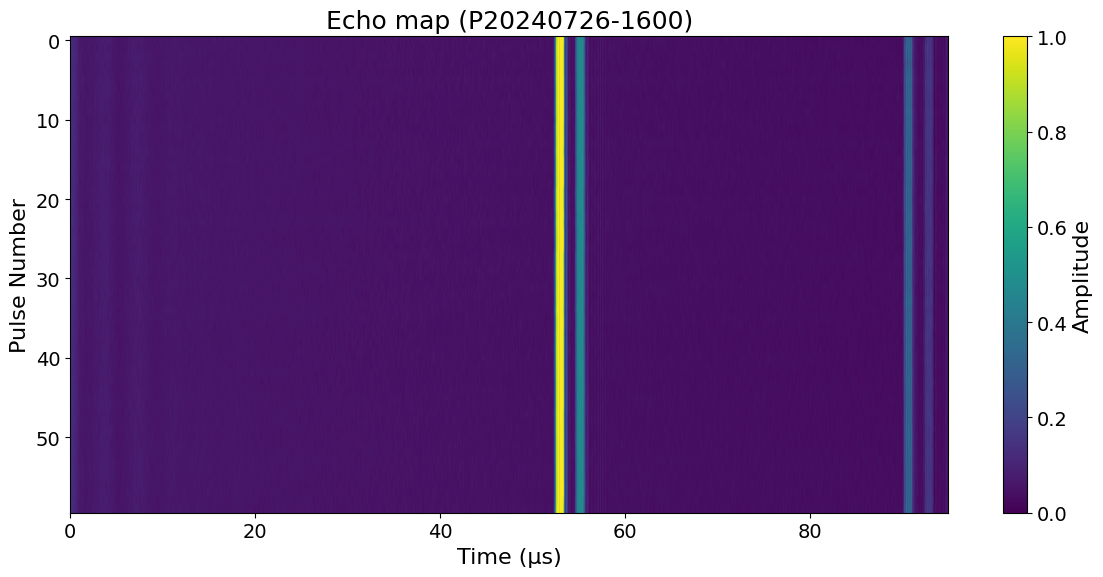

<Figure size 1500x1200 with 0 Axes>

In [1]:
from src import generate_echomap

file_path = "/home/matsubara/database/signal_mat/P20240726-1600.mat"
save_dir = "/home/matsubara/database/tmp"
triggered_pulses, adjusted_time_us, mean_pulse, std_pulse = generate_echomap(
    file_path, 
    start_time=2, 
    duration=0.02,
    window_width=100e-6, 
    amplitude_threshold=2.0, 
    output_dir=save_dir)

## トリガー検出
超音波波形データを画像に変換する上で最も重要なのは、その信号を並び替えるということです。特に超音波を照射するためにトランスデューサを強制的に振動させた点を起点として、そこから信号を並べるという操作が重要になります。
これらファイルの共通する性質として、超音波を３ｋHzで5秒間照射し、その反射波や透過波を計測した信号波形であるというものがあります。これらによって3つのトランスデューサに信号波形が記録されるという形式になります。
ではここで、一つの信号からトリガーを検出する、という関数を実行して挙動を見てみましょう。
### 注）
見るべき系の大きさは大体150㎜程度、すなわち音波にして100μsの領域です。つまり、一秒間に照射できる回数は、最大でも10k回です。現在は3khzの設定なので、見るべき時間幅は0.1msとしています。

In [21]:
from src import detect_triggers_from_signal
if __name__ == "__main__":
    # Example of detection from MAT file
    try:
        file_path = "/home/matsubara/database/signal_mat/P20241203-1005.mat"
        start_time = 0.0  # Start time in seconds
        duration = 1.0   # Duration in seconds
        amplitude_threshold = 2  # Amplitude threshold
        
        triggers, signal_chunk, fs = detect_triggers_from_signal(
            file_path=file_path,
            start_time=start_time,
            duration=duration,
            amplitude_threshold=amplitude_threshold,
            window_width=0.0001  # 0.1ms
        )
        
        print(f"Sampling frequency: {fs} Hz")
        print(f"Detected triggers: {len(triggers)}")
        print(f"Signal chunk length: {len(signal_chunk)} samples")
        
        # Display trigger times in seconds
        trigger_times = [t / fs for t in triggers]
        print(f"Trigger times (per seconds): {len(trigger_times)}")
        
    except Exception as e:
        print(f"Error: {e}") 

Loading data...
Loading successful
Using device: cuda:0
Number of detected triggers: (2988,)
Sampling frequency: 52083333.842615336 Hz
Detected triggers: 2988
Signal chunk length: 52083333 samples
Trigger times (per seconds): 2988


## 画像化
これら検出されたトリガー点から300μsの範囲を切り出し、縦に並べたものが以下のようになります。左が生波形のプロット、右がヒルベルト変換後のプロットを示しています。

In [22]:
import numpy as np
import scipy.io as sio
import torch
import matplotlib.pyplot as plt
from scipy.signal import hilbert
import os
from src import extract_waveforms_with_hilbert, extract_waveforms_from_trigger_times,detect_triggers_from_signal

# 使用例
if __name__ == "__main__":
    
    file_path = "/home/matsubara/database/signal_mat/P20241203-1005.mat"
    start_time = 1e-9
    duration = 1
    amplitude_threshold = 2.0
    
    # 1. TDX1からトリガーを検出
    trigger_points, chunk, Fs = detect_triggers_from_signal(
        file_path=file_path,
        start_time=start_time,
        duration=duration,
        amplitude_threshold=amplitude_threshold,
        window_width=0.0001  # 0.1ms
    )
    
    # トリガー時刻を計算
    trigger_times = np.array(trigger_points) / Fs + start_time
    
    # 2. 全チャンネルから300μsの波形を切り出し（ヒルベルト変換込み）
    channels = ["TDX1", "TDX2", "TDX3", "TDX1_enlarged"]
    results = extract_waveforms_with_hilbert(
        file_path=file_path,
        channels=channels,
        trigger_times=trigger_times,
        starting_window=2e-6,  # -50μs
        ending_window=250e-6,    # +250μs（合計300μs）
        neglect_time=1e-6,      # 初期55μsを除去
        output_dir="/home/matsubara/database/tmp"
    )
    
    # 3. 平均波形をプロット
    #plot_average_waveforms(results, output_dir="/home/matsubara/database/tmp")
    
    print("\n=== Processing Complete ===")
    for channel, data in results.items():
        print(f"{channel}: {data['n_pulses']} pulses processed")

Loading data...
Loading successful
Using device: cuda:0
Number of detected triggers: (2988,)
Loading data...
Loading successful
Using device: cuda
Number of pulses: 2988
Window width: 248.0 μs
Neglect time: 1.0 μs
Processing channel TDX1...
Applying Hilbert transform to 2988 pulses...
Channel TDX1: Processed 2988 pulses
Hilbert matrix shape: (2988, 12916)
Trimmed matrix shape: (2988, 12864)
Saved comparison image: /home/matsubara/database/tmp/P20241203-1005_TDX1_hilbert_comparison.png
Saved Hilbert image: /home/matsubara/database/tmp/P20241203-1005_TDX1_hilbert_only.png
Processing channel TDX2...
Applying Hilbert transform to 2988 pulses...
Channel TDX2: Processed 2988 pulses
Hilbert matrix shape: (2988, 12916)
Trimmed matrix shape: (2988, 12864)
Saved comparison image: /home/matsubara/database/tmp/P20241203-1005_TDX2_hilbert_comparison.png
Saved Hilbert image: /home/matsubara/database/tmp/P20241203-1005_TDX2_hilbert_only.png
Processing channel TDX3...
Applying Hilbert transform to 298

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

## フーリエ変換と時刻指定
ここで、フーリエ変換とヒルベルト変換についておさらいします。これらは信号波形に対する処理ですが、信号はデジタルに点数で表現されるので、連続関数としての取り扱いが難しいです。そこで、デジタルな値に対する処理を行います。しかし、これでは時刻と点数がきっちり一致することが少ないので、処理および変更が必要です。ここでは、その部分についてまとめます。

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from src import npz2png
# データの読み込み
file_path = "/mnt/matsubara/signals_exp/processed_data/all/P20240729-1423_processed.npz"
npz2png(file_path,save_path="/mnt/matsubara/outputs/logs",full=False)
x=np.load(file_path,allow_pickle=True)
pulse= x['processed_data'][0,:,0]
print(pulse.shape)


/mnt/matsubara/outputs/logs/P20240729-1423_processed_0pulse0.png
(2500,)


サンプリング周波数: 52083333.842615336 Hz
パルスの形状: (2500,)

抽出範囲: 0.0～15.0 μs
抽出インデックス: 0～781
抽出されたサンプル数: 781
抽出された時間範囲: 0.00～14.98 μs


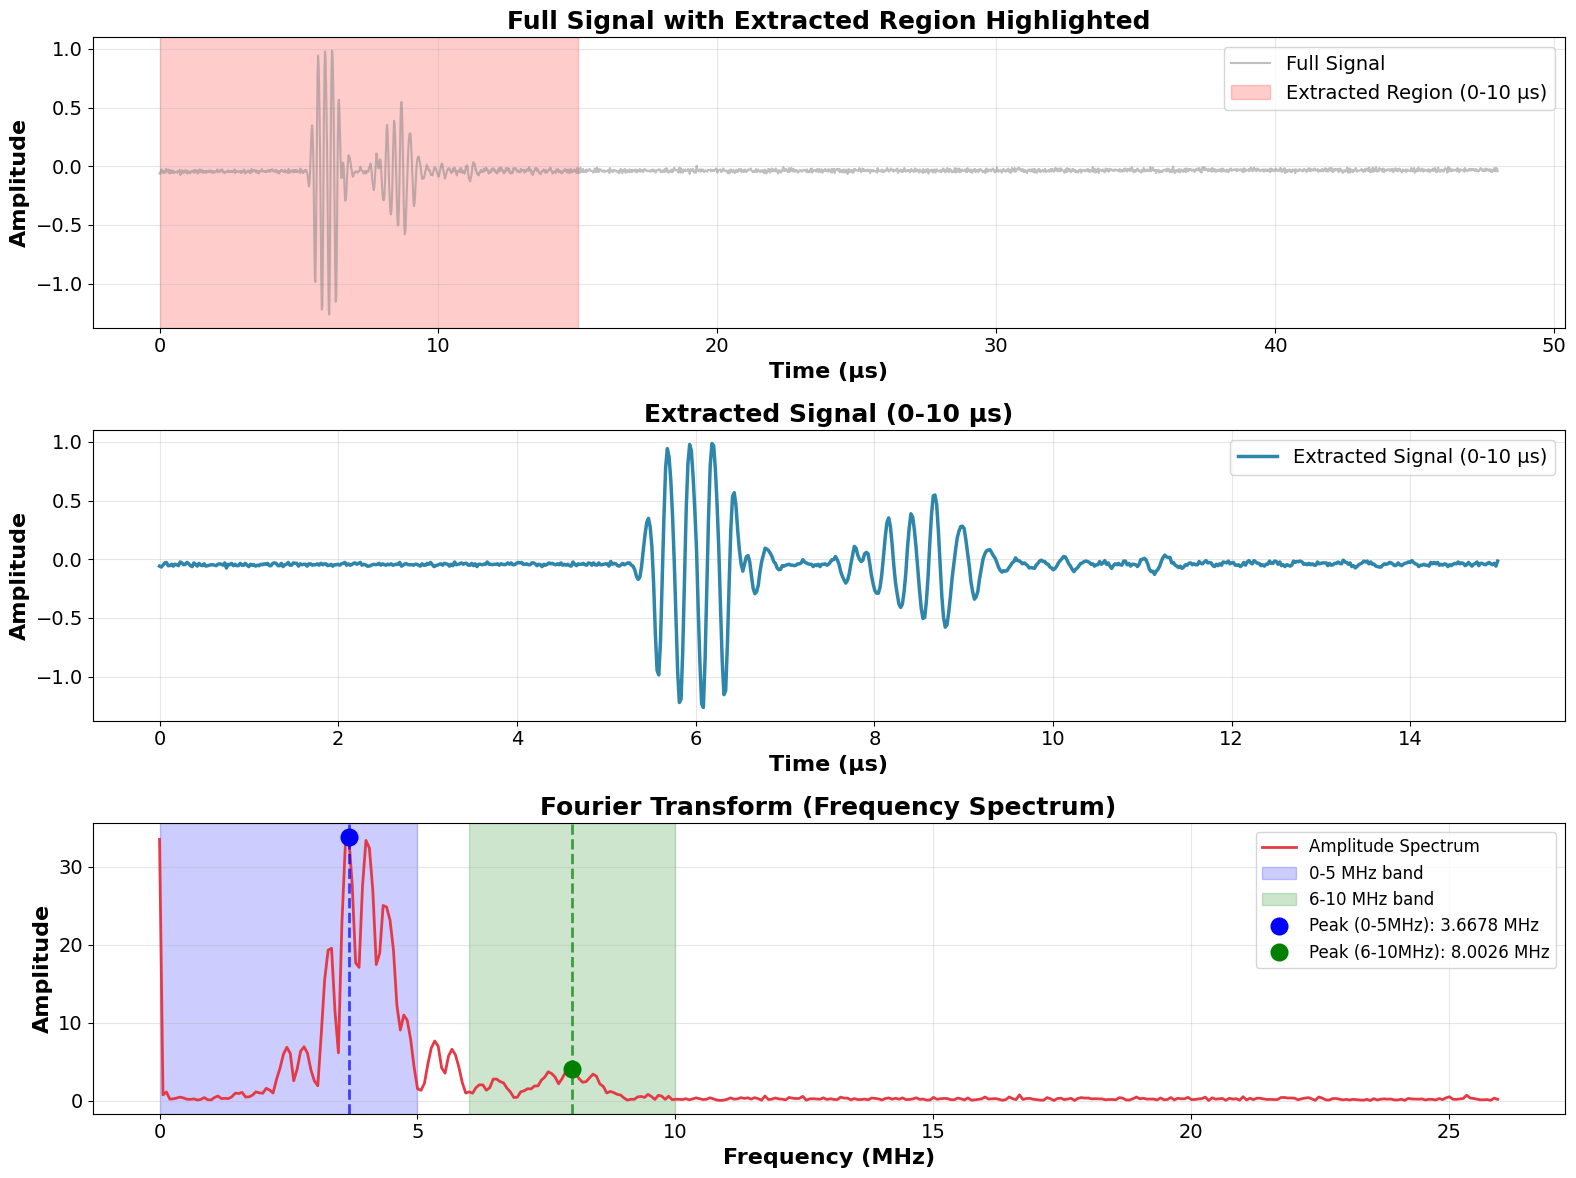


【抽出された信号の統計情報】
  時間範囲: 0.0000～14.9760 μs
  時間幅: 14.9760 μs
  サンプル数: 781
  振幅範囲: -1.2642～0.9863
  最大振幅: 0.9863 (位置: 6.1824 μs)
  最小振幅: -1.2642 (位置: 6.0864 μs)
  平均振幅: -0.0429
  標準偏差: 0.2089

【フーリエ変換の統計情報】
  周波数分解能: 0.0667 MHz
  ナイキスト周波数: 25.9416 MHz

【周波数帯域別の最大値】
  0～5MHz帯:
    最大値周波数: 3.6678 MHz
    最大振幅値: 33.8757
  6～10MHz帯:
    最大値周波数: 8.0026 MHz
    最大振幅値: 4.1362


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from src import npz2png

# データの読み込み
file_path = "/mnt/matsubara/signals_exp/processed_data/all/P20240729-1423_processed.npz"
x = np.load(file_path, allow_pickle=True)

# サンプリング周波数を取得
fs = x['fs'].item() if hasattr(x['fs'], 'item') else float(x['fs'])
print(f"サンプリング周波数: {fs} Hz")

# パルスデータを取得
pulse = x['processed_data'][0, :, 0]
print(f"パルスの形状: {pulse.shape}")

# 時間軸を計算（秒単位）
n_samples = len(pulse)
time_seconds = np.arange(n_samples) / fs
time_microseconds = time_seconds * 1e6  # マイクロ秒に変換

# 0～10μsの範囲を抽出
start_time_us = 0.0   # 開始時間（μs）
end_time_us = 15.0    # 終了時間（μs）

# インデックスを計算
start_idx = int(start_time_us * 1e-6 * fs)  # 0μs = 0秒
end_idx = int(end_time_us * 1e-6 * fs)       # 10μs = 0.00001秒

# 範囲を抽出
pulse_extracted = pulse[start_idx:end_idx]
time_extracted = time_microseconds[start_idx:end_idx]

print(f"\n抽出範囲: {start_time_us}～{end_time_us} μs")
print(f"抽出インデックス: {start_idx}～{end_idx}")
print(f"抽出されたサンプル数: {len(pulse_extracted)}")
print(f"抽出された時間範囲: {time_extracted[0]:.2f}～{time_extracted[-1]:.2f} μs")

# フーリエ変換を実施
# FFTを計算
fft_result = fft(pulse_extracted)
fft_magnitude = np.abs(fft_result)  # 振幅スペクトル
fft_power = fft_magnitude ** 2      # パワースペクトル

# 周波数軸を計算（Hz）
n_fft = len(pulse_extracted)
frequencies = fftfreq(n_fft, 1/fs)  # 周波数（Hz）
frequencies_mhz = frequencies / 1e6  # 周波数（MHz）

# 正の周波数のみを表示（ナイキスト周波数まで）
nyquist_idx = n_fft // 2
freq_positive = frequencies_mhz[:nyquist_idx]
magnitude_positive = fft_magnitude[:nyquist_idx]
power_positive = fft_power[:nyquist_idx]

# 0～5MHz帯と6～10MHz帯の最大値を検出
# 0～5MHz帯
mask_0_5mhz = (freq_positive >= 0) & (freq_positive <= 5.0)
if np.any(mask_0_5mhz):
    idx_0_5mhz = np.where(mask_0_5mhz)[0]
    max_idx_0_5mhz = idx_0_5mhz[np.argmax(magnitude_positive[mask_0_5mhz])]
    max_freq_0_5mhz = freq_positive[max_idx_0_5mhz]
    max_magnitude_0_5mhz = magnitude_positive[max_idx_0_5mhz]
else:
    max_freq_0_5mhz = None
    max_magnitude_0_5mhz = None

# 6～10MHz帯
mask_6_10mhz = (freq_positive >= 6.0) & (freq_positive <= 10.0)
if np.any(mask_6_10mhz):
    idx_6_10mhz = np.where(mask_6_10mhz)[0]
    max_idx_6_10mhz = idx_6_10mhz[np.argmax(magnitude_positive[mask_6_10mhz])]
    max_freq_6_10mhz = freq_positive[max_idx_6_10mhz]
    max_magnitude_6_10mhz = magnitude_positive[max_idx_6_10mhz]
else:
    max_freq_6_10mhz = None
    max_magnitude_6_10mhz = None

# プロット（3つのサブプロット）
fig = plt.figure(figsize=(16, 12))

# 上段: 全体の信号
ax1 = plt.subplot(3, 1, 1)
ax1.plot(time_microseconds, pulse, linewidth=1.5, color='gray', alpha=0.5, label='Full Signal')
ax1.axvspan(start_time_us, end_time_us, alpha=0.2, color='red', label='Extracted Region (0-10 μs)')
ax1.set_xlabel('Time (μs)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=16, fontweight='bold')
ax1.set_title('Full Signal with Extracted Region Highlighted', fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=14)

# 中段: 抽出された範囲（0～10μs）
ax2 = plt.subplot(3, 1, 2)
ax2.plot(time_extracted, pulse_extracted, linewidth=2.5, color='#2E86AB', label='Extracted Signal (0-10 μs)')
ax2.set_xlabel('Time (μs)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Amplitude', fontsize=16, fontweight='bold')
ax2.set_title('Extracted Signal (0-10 μs)', fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=14)

# 下段: フーリエ変換結果（周波数スペクトル）
ax3 = plt.subplot(3, 1, 3)
ax3.plot(freq_positive, magnitude_positive, linewidth=2, color='#E63946', label='Amplitude Spectrum')

# 0～5MHz帯と6～10MHz帯の範囲をハイライト
ax3.axvspan(0, 5, alpha=0.2, color='blue', label='0-5 MHz band')
ax3.axvspan(6, 10, alpha=0.2, color='green', label='6-10 MHz band')

# 最大値をマーク
if max_freq_0_5mhz is not None:
    ax3.plot(max_freq_0_5mhz, max_magnitude_0_5mhz, 'bo', markersize=12, 
             label=f'Peak (0-5MHz): {max_freq_0_5mhz:.4f} MHz')
    ax3.axvline(max_freq_0_5mhz, color='blue', linestyle='--', linewidth=2, alpha=0.7)

if max_freq_6_10mhz is not None:
    ax3.plot(max_freq_6_10mhz, max_magnitude_6_10mhz, 'go', markersize=12, 
             label=f'Peak (6-10MHz): {max_freq_6_10mhz:.4f} MHz')
    ax3.axvline(max_freq_6_10mhz, color='green', linestyle='--', linewidth=2, alpha=0.7)

ax3.set_xlabel('Frequency (MHz)', fontsize=16, fontweight='bold')
ax3.set_ylabel('Amplitude', fontsize=16, fontweight='bold')
ax3.set_title('Fourier Transform (Frequency Spectrum)', fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=12, loc='best')
ax3.tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.show()

# 統計情報
print(f"\n{'='*60}")
print(f"【抽出された信号の統計情報】")
print(f"  時間範囲: {time_extracted[0]:.4f}～{time_extracted[-1]:.4f} μs")
print(f"  時間幅: {time_extracted[-1] - time_extracted[0]:.4f} μs")
print(f"  サンプル数: {len(pulse_extracted)}")
print(f"  振幅範囲: {pulse_extracted.min():.4f}～{pulse_extracted.max():.4f}")
print(f"  最大振幅: {pulse_extracted.max():.4f} (位置: {time_extracted[np.argmax(pulse_extracted)]:.4f} μs)")
print(f"  最小振幅: {pulse_extracted.min():.4f} (位置: {time_extracted[np.argmin(pulse_extracted)]:.4f} μs)")
print(f"  平均振幅: {pulse_extracted.mean():.4f}")
print(f"  標準偏差: {pulse_extracted.std():.4f}")

print(f"\n【フーリエ変換の統計情報】")
print(f"  周波数分解能: {frequencies_mhz[1] - frequencies_mhz[0]:.4f} MHz")
print(f"  ナイキスト周波数: {frequencies_mhz[nyquist_idx-1]:.4f} MHz")

print(f"\n【周波数帯域別の最大値】")
if max_freq_0_5mhz is not None:
    print(f"  0～5MHz帯:")
    print(f"    最大値周波数: {max_freq_0_5mhz:.4f} MHz")
    print(f"    最大振幅値: {max_magnitude_0_5mhz:.4f}")
else:
    print(f"  0～5MHz帯: データなし")

if max_freq_6_10mhz is not None:
    print(f"  6～10MHz帯:")
    print(f"    最大値周波数: {max_freq_6_10mhz:.4f} MHz")
    print(f"    最大振幅値: {max_magnitude_6_10mhz:.4f}")
else:
    print(f"  6～10MHz帯: データなし")

print(f"{'='*60}")

サンプリング周波数: 999999999.9999999 Hz
パルスの形状: (50000,)

抽出範囲: 0.0～10.0 μs
抽出インデックス: 0～9999
抽出されたサンプル数: 9999
抽出された時間範囲: 0.00～10.00 μs


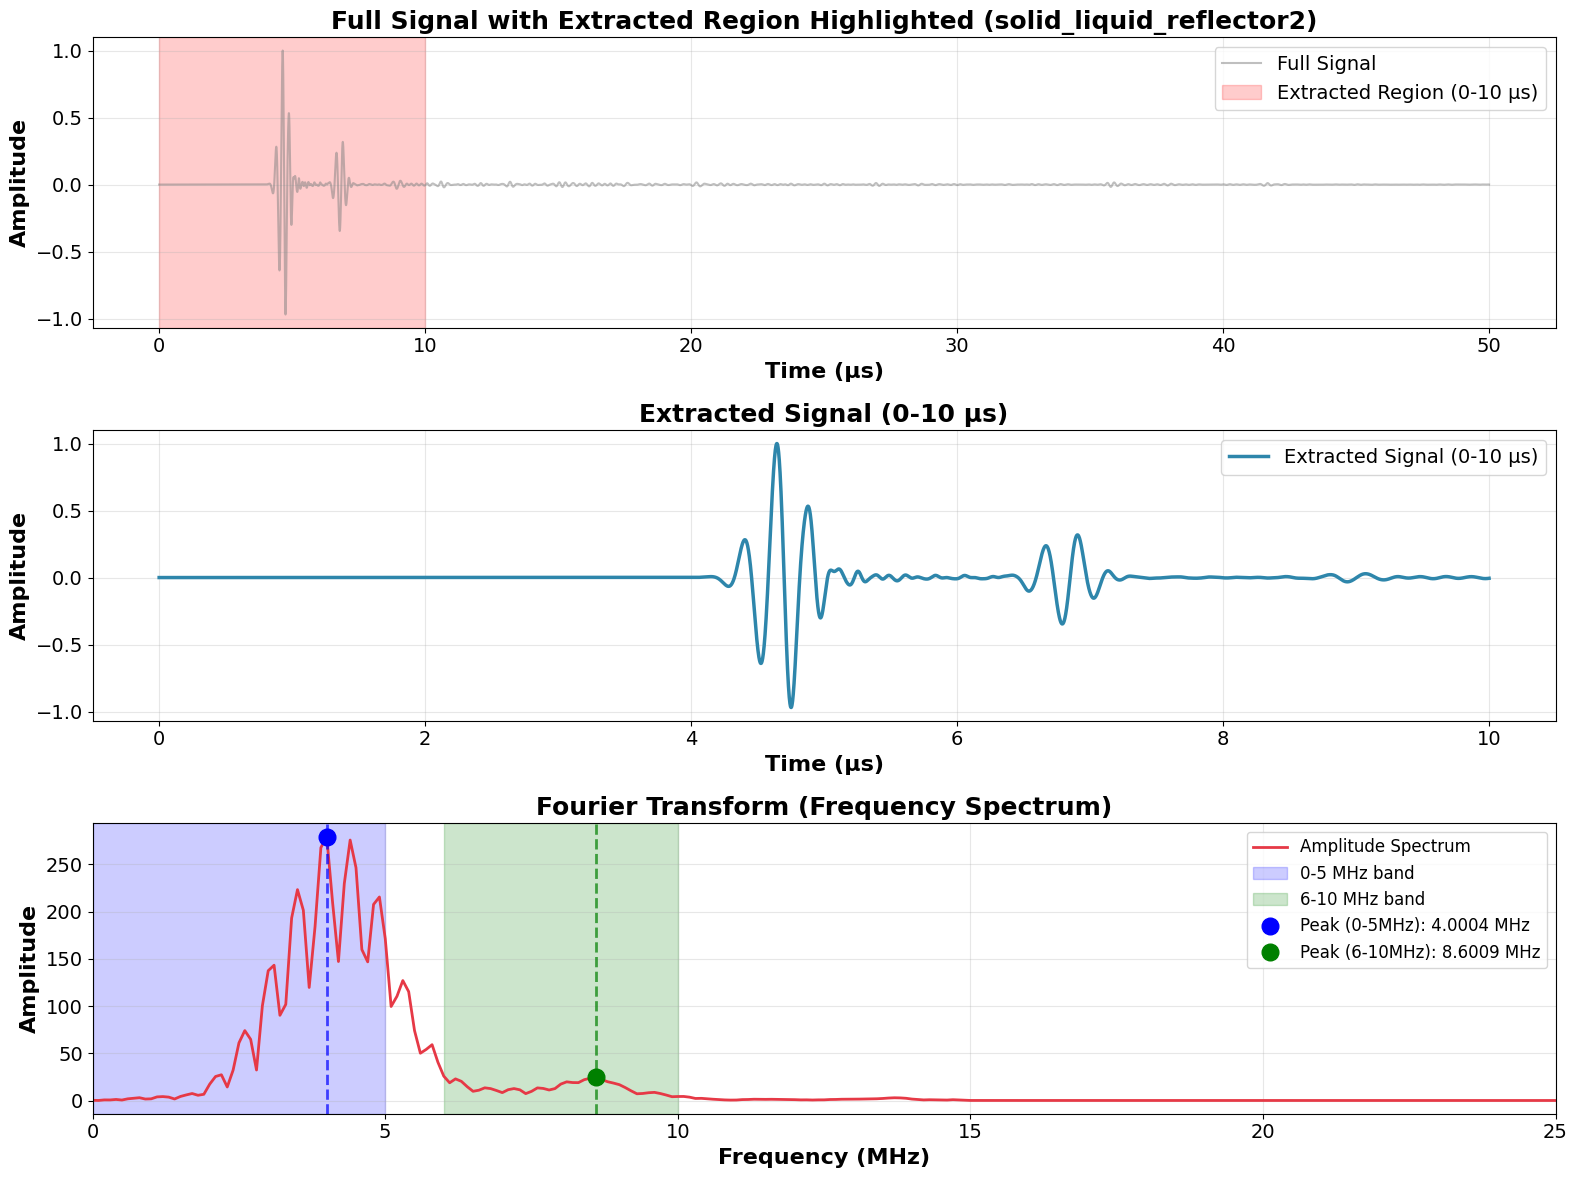


【ファイル: solid_liquid_reflector2_processed.npz】
【抽出された信号の統計情報】
  時間範囲: 0.0000～9.9980 μs
  時間幅: 9.9980 μs
  サンプル数: 9999
  振幅範囲: -0.9698～1.0000
  最大振幅: 1.0000 (位置: 4.6440 μs)
  最小振幅: -0.9698 (位置: 4.7510 μs)
  平均振幅: -0.0000
  標準偏差: 0.1348

【フーリエ変換の統計情報】
  周波数分解能: 0.1000 MHz
  ナイキスト周波数: 499.8500 MHz

【周波数帯域別の最大値】
  0～5MHz帯:
    最大値周波数: 4.0004 MHz
    最大振幅値: 279.4139
  6～10MHz帯:
    最大値周波数: 8.6009 MHz
    最大振幅値: 24.6670


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from src import npz2png

# データの読み込み（solid_liquid_reflector2_processed.npz）
file_path = "/mnt/matsubara/signals_sim/examples/processed/solid_liquid_reflector9_processed.npz"
x = np.load(file_path, allow_pickle=True)

# サンプリング周波数を取得
fs = x['fs'].item() if hasattr(x['fs'], 'item') else float(x['fs'])
print(f"サンプリング周波数: {fs} Hz")

# パルスデータを取得
pulse = x['processed_data'][0, :, 0]
print(f"パルスの形状: {pulse.shape}")

# パルス波形を最大値で正規化（最大値が1になるように）
pulse = pulse / np.max(np.abs(pulse))
# 時間軸を計算（秒単位）
n_samples = len(pulse)
time_seconds = np.arange(n_samples) / fs
time_microseconds = time_seconds * 1e6  # マイクロ秒に変換

# 0～10μsの範囲を抽出
start_time_us = 0.0   # 開始時間（μs）
end_time_us = 10.0    # 終了時間（μs）

# インデックスを計算
start_idx = int(start_time_us * 1e-6 * fs)  # 0μs = 0秒
end_idx = int(end_time_us * 1e-6 * fs)       # 10μs = 0.00001秒

# 範囲を抽出
pulse_extracted = pulse[start_idx:end_idx]
time_extracted = time_microseconds[start_idx:end_idx]

print(f"\n抽出範囲: {start_time_us}～{end_time_us} μs")
print(f"抽出インデックス: {start_idx}～{end_idx}")
print(f"抽出されたサンプル数: {len(pulse_extracted)}")
print(f"抽出された時間範囲: {time_extracted[0]:.2f}～{time_extracted[-1]:.2f} μs")

# フーリエ変換を実施
# FFTを計算
fft_result = fft(pulse_extracted)
fft_magnitude = np.abs(fft_result)  # 振幅スペクトル
fft_power = fft_magnitude ** 2      # パワースペクトル

# 周波数軸を計算（Hz）
n_fft = len(pulse_extracted)
frequencies = fftfreq(n_fft, 1/fs)  # 周波数（Hz）
frequencies_mhz = frequencies / 1e6  # 周波数（MHz）

# 正の周波数のみを表示（ナイキスト周波数まで）
nyquist_idx = n_fft // 2
freq_positive = frequencies_mhz[:nyquist_idx]
magnitude_positive = fft_magnitude[:nyquist_idx]
power_positive = fft_power[:nyquist_idx]

# 0～5MHz帯と6～10MHz帯の最大値を検出
# 0～5MHz帯
mask_0_5mhz = (freq_positive >= 0) & (freq_positive <= 5.0)
if np.any(mask_0_5mhz):
    idx_0_5mhz = np.where(mask_0_5mhz)[0]
    max_idx_0_5mhz = idx_0_5mhz[np.argmax(magnitude_positive[mask_0_5mhz])]
    max_freq_0_5mhz = freq_positive[max_idx_0_5mhz]
    max_magnitude_0_5mhz = magnitude_positive[max_idx_0_5mhz]
else:
    max_freq_0_5mhz = None
    max_magnitude_0_5mhz = None

# 6～10MHz帯
mask_6_10mhz = (freq_positive >= 7.0) & (freq_positive <= 10.0)
if np.any(mask_6_10mhz):
    idx_6_10mhz = np.where(mask_6_10mhz)[0]
    max_idx_6_10mhz = idx_6_10mhz[np.argmax(magnitude_positive[mask_6_10mhz])]
    max_freq_6_10mhz = freq_positive[max_idx_6_10mhz]
    max_magnitude_6_10mhz = magnitude_positive[max_idx_6_10mhz]
else:
    max_freq_6_10mhz = None
    max_magnitude_6_10mhz = None

# プロット（3つのサブプロット）
fig = plt.figure(figsize=(16, 12))

# 上段: 全体の信号
ax1 = plt.subplot(3, 1, 1)
ax1.plot(time_microseconds, pulse, linewidth=1.5, color='gray', alpha=0.5, label='Full Signal')
ax1.axvspan(start_time_us, end_time_us, alpha=0.2, color='red', label='Extracted Region (0-10 μs)')
ax1.set_xlabel('Time (μs)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=16, fontweight='bold')
ax1.set_title('Full Signal with Extracted Region Highlighted (solid_liquid_reflector2)', fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=14)

# 中段: 抽出された範囲（0～10μs）
ax2 = plt.subplot(3, 1, 2)
ax2.plot(time_extracted, pulse_extracted, linewidth=2.5, color='#2E86AB', label='Extracted Signal (0-10 μs)')
ax2.set_xlabel('Time (μs)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Amplitude', fontsize=16, fontweight='bold')
ax2.set_title('Extracted Signal (0-10 μs)', fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=14)
ax2.tick_params(axis='both', which='major', labelsize=14)

# 下段: フーリエ変換結果（周波数スペクトル）
ax3 = plt.subplot(3, 1, 3)
ax3.plot(freq_positive, magnitude_positive, linewidth=2, color='#E63946', label='Amplitude Spectrum')

# 0～5MHz帯と6～10MHz帯の範囲をハイライト
ax3.axvspan(0, 5, alpha=0.2, color='blue', label='0-5 MHz band')
ax3.axvspan(6, 10, alpha=0.2, color='green', label='6-10 MHz band')

# 最大値をマーク
if max_freq_0_5mhz is not None:
    ax3.plot(max_freq_0_5mhz, max_magnitude_0_5mhz, 'bo', markersize=12, 
             label=f'Peak (0-5MHz): {max_freq_0_5mhz:.4f} MHz')
    ax3.axvline(max_freq_0_5mhz, color='blue', linestyle='--', linewidth=2, alpha=0.7)

if max_freq_6_10mhz is not None:
    ax3.plot(max_freq_6_10mhz, max_magnitude_6_10mhz, 'go', markersize=12, 
             label=f'Peak (6-10MHz): {max_freq_6_10mhz:.4f} MHz')
    ax3.axvline(max_freq_6_10mhz, color='green', linestyle='--', linewidth=2, alpha=0.7)

ax3.set_xlabel('Frequency (MHz)', fontsize=16, fontweight='bold')
ax3.set_ylabel('Amplitude', fontsize=16, fontweight='bold')
ax3.set_title('Fourier Transform (Frequency Spectrum)', fontsize=18, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=12, loc='best')
ax3.tick_params(axis='both', which='major', labelsize=14)
ax3.set_xlim(0, 25)

plt.tight_layout()
plt.show()

# 統計情報
print(f"\n{'='*60}")
print(f"【ファイル: solid_liquid_reflector2_processed.npz】")
print(f"【抽出された信号の統計情報】")
print(f"  時間範囲: {time_extracted[0]:.4f}～{time_extracted[-1]:.4f} μs")
print(f"  時間幅: {time_extracted[-1] - time_extracted[0]:.4f} μs")
print(f"  サンプル数: {len(pulse_extracted)}")
print(f"  振幅範囲: {pulse_extracted.min():.4f}～{pulse_extracted.max():.4f}")
print(f"  最大振幅: {pulse_extracted.max():.4f} (位置: {time_extracted[np.argmax(pulse_extracted)]:.4f} μs)")
print(f"  最小振幅: {pulse_extracted.min():.4f} (位置: {time_extracted[np.argmin(pulse_extracted)]:.4f} μs)")
print(f"  平均振幅: {pulse_extracted.mean():.4f}")
print(f"  標準偏差: {pulse_extracted.std():.4f}")

print(f"\n【フーリエ変換の統計情報】")
print(f"  周波数分解能: {frequencies_mhz[1] - frequencies_mhz[0]:.4f} MHz")
print(f"  ナイキスト周波数: {frequencies_mhz[nyquist_idx-1]:.4f} MHz")

print(f"\n【周波数帯域別の最大値】")
if max_freq_0_5mhz is not None:
    print(f"  0～5MHz帯:")
    print(f"    最大値周波数: {max_freq_0_5mhz:.4f} MHz")
    print(f"    最大振幅値: {max_magnitude_0_5mhz:.4f}")
else:
    print(f"  0～5MHz帯: データなし")

if max_freq_6_10mhz is not None:
    print(f"  6～10MHz帯:")
    print(f"    最大値周波数: {max_freq_6_10mhz:.4f} MHz")
    print(f"    最大振幅値: {max_magnitude_6_10mhz:.4f}")
else:
    print(f"  6～10MHz帯: データなし")

print(f"{'='*60}")

In [31]:
sim_data_path="/mnt/matsubara/signals_sim/examples/processed/case5/solid_liquid3_processed.npz"
exp_data_path="/mnt/matsubara/signals_exp/processed_data/all/P20241018-1612_processed.npz"
x=np.load(sim_data_path,allow_pickle=True)
print(x.keys())
print(x['processed_data'].shape)
from src import npz2png
npz2png(sim_data_path,save_path="/mnt/matsubara/outputs/logs",full=False,pulse_index=0)



KeysView(<numpy.lib.npyio.NpzFile object at 0x1502939dee30>)
(1, 50000, 1)
/mnt/matsubara/outputs/logs/solid_liquid3_processed_0pulse0.png


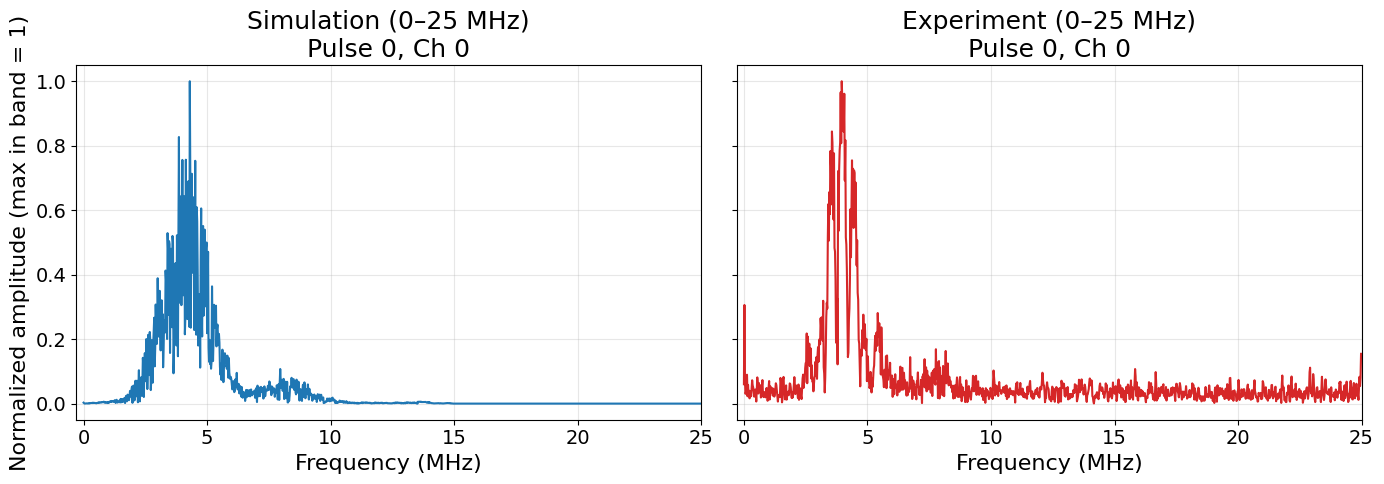

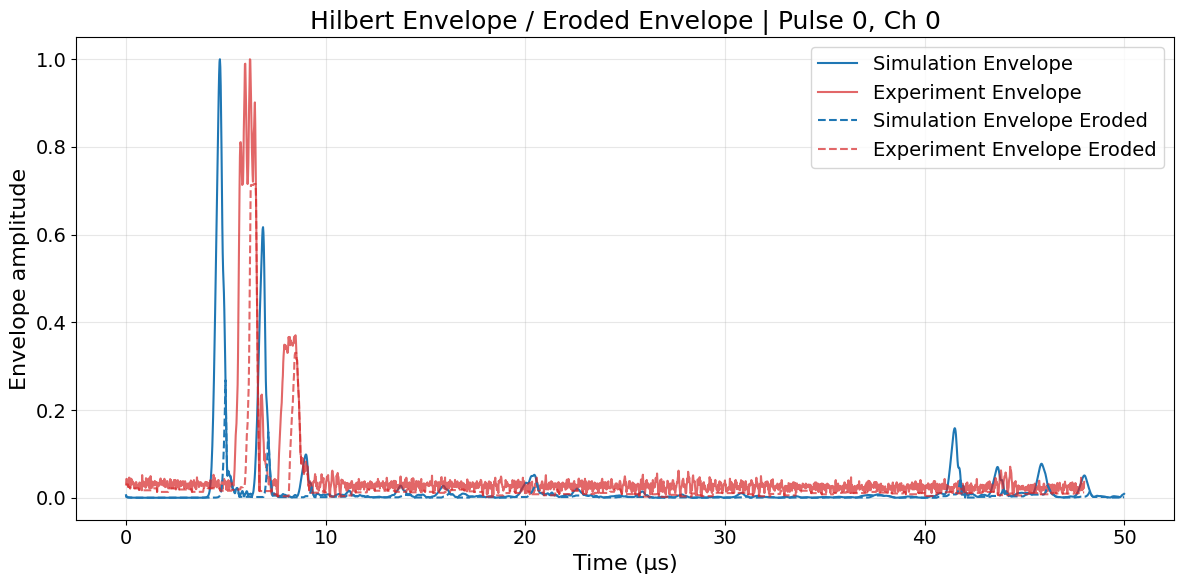

=== 信号比較: 0–10μs区間 ===
シミュレーション: 絶対値和 = 36.545662, 二乗和 = 19.163560
実機:           絶対値和 = 74.266762, 二乗和 = 38.654210
実機(可変正規化):        絶対値和 = 49.511174, 二乗和 = 17.179649
シミュレーション(eroded): 絶対値和 = 4.414768, 二乗和 = 0.436079
実機(eroded):           絶対値和 = 31.526689, 二乗和 = 11.655155


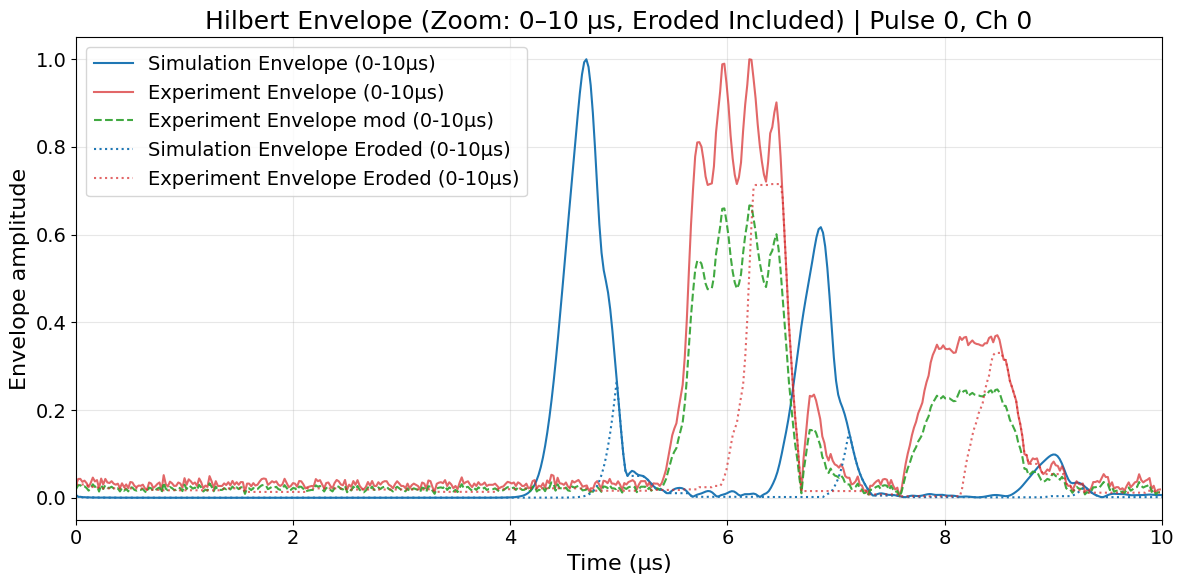

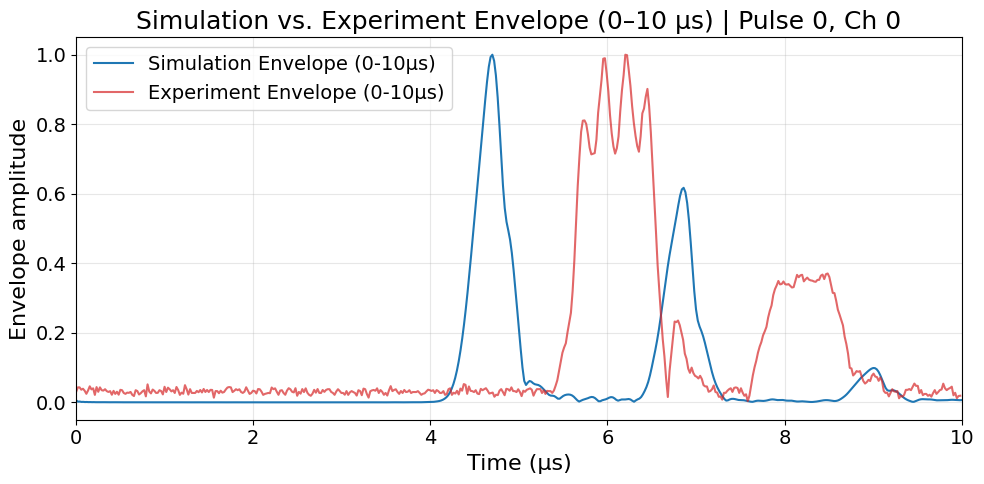

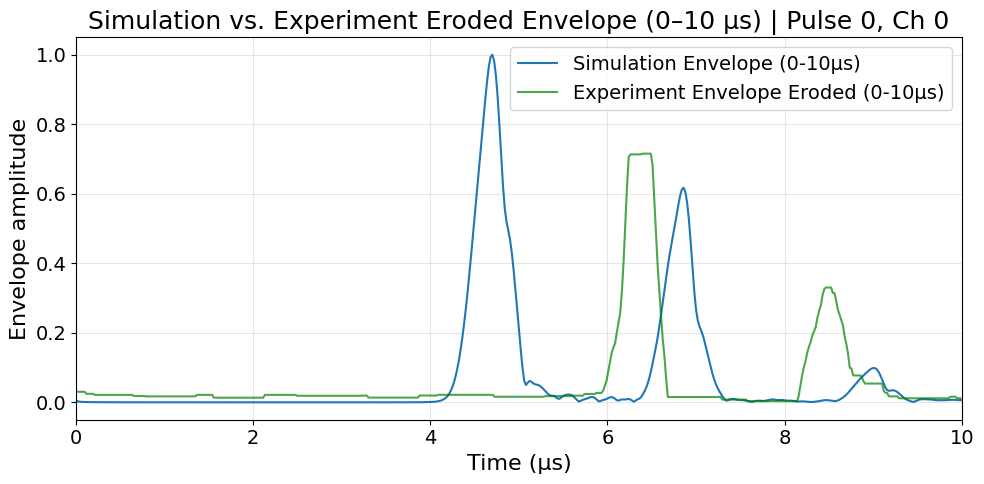

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 設定 ----
pulse_index = 0
channel_index = 0

sim_downsample = 20      # シミュレーションだけ間引く（不要なら 1）
sim_fmax_MHz = 25
exp_fmax_MHz = 25

use_hann = True          # スペクトルを見やすくしたいなら True
remove_dc = True         # 平均値を引いて DC を抑えるなら True

# ---- 読み込み ----
def load_pulse_and_fs(npz_path, pulse_index=0, channel_index=0):
    data = np.load(npz_path, allow_pickle=True)
    fs = data["fs"].item() if hasattr(data["fs"], "item") else float(data["fs"])
    pulse = data["processed_data"][pulse_index, :, channel_index].astype(np.float64)
    return pulse, fs

sim_pulse, sim_fs = load_pulse_and_fs(sim_data_path, pulse_index, channel_index)
exp_pulse, exp_fs = load_pulse_and_fs(exp_data_path, pulse_index, channel_index)

# シミュレーションだけダウンサンプリング
if sim_downsample > 1:
    sim_pulse = sim_pulse[::sim_downsample]
    sim_fs = sim_fs / sim_downsample

# ---- FFT（片側スペクトル）----
def spectrum_rfft(pulse, fs, remove_dc=True, use_hann=True):
    x = pulse.copy()
    if remove_dc:
        x = x - np.mean(x)

    if use_hann:
        w = np.hanning(len(x))
        x = x * w

    X = np.fft.rfft(x)
    f_Hz = np.fft.rfftfreq(len(x), d=1.0/fs)
    mag = np.abs(X)
    f_MHz = f_Hz / 1e6
    return f_MHz, mag

sim_f, sim_mag = spectrum_rfft(sim_pulse, sim_fs, remove_dc=remove_dc, use_hann=use_hann)
exp_f, exp_mag = spectrum_rfft(exp_pulse, exp_fs, remove_dc=remove_dc, use_hann=use_hann)

# 表示帯域内で正規化（0〜fmax の最大が 1 になる）
def normalize_in_band(f, mag, fmax):
    mask = (f >= 0) & (f <= fmax)
    m = mag[mask]
    denom = np.max(m) if m.size and np.max(m) > 0 else 1.0
    return mag / denom

sim_mag_n = normalize_in_band(sim_f, sim_mag, sim_fmax_MHz)
exp_mag_n = normalize_in_band(exp_f, exp_mag, exp_fmax_MHz)

# ---- プロット ----
plt.rcParams["font.size"] = 12
fig, (ax_sim, ax_exp) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 左：シミュレーション（0–10 MHz）
mask_sim = (sim_f >= 0) & (sim_f <= sim_fmax_MHz)
ax_sim.plot(sim_f[mask_sim], sim_mag_n[mask_sim], color="#1f77b4")
ax_sim.set_xlim(-0.3, sim_fmax_MHz)
ax_sim.set_xlabel("Frequency (MHz)")
ax_sim.set_ylabel("Normalized amplitude (max in band = 1)")
ax_sim.set_title(f"Simulation (0–{sim_fmax_MHz} MHz)\nPulse {pulse_index}, Ch {channel_index}")
ax_sim.grid(True, alpha=0.3)

# 右：実機（0–13 MHz）
mask_exp = (exp_f >= 0) & (exp_f <= exp_fmax_MHz)
ax_exp.plot(exp_f[mask_exp], exp_mag_n[mask_exp], color="#d62728")
ax_exp.set_xlim(-0.3, exp_fmax_MHz)
ax_exp.set_xlabel("Frequency (MHz)")
ax_exp.set_title(f"Experiment (0–{exp_fmax_MHz} MHz)\nPulse {pulse_index}, Ch {channel_index}")
ax_exp.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- ヒルベルト変換後の包絡線（絶対値）を重ねて表示 ----
from scipy.signal import hilbert

# シミュレーション・実験パルスを正規化せず、ヒルベルト変換した包絡線(絶対値)を計算
sim_envelope = np.abs(hilbert(sim_pulse))
exp_envelope = np.abs(hilbert(exp_pulse))

# 包絡線の最大値から両者を正規化（同一スケールで比較）
sim_env_max = np.max(sim_envelope) if np.max(sim_envelope) > 0 else 1.0
exp_env_max = np.max(exp_envelope) if np.max(exp_envelope) > 0 else 1.0

# オリジナルのenvelope
sim_envelope = sim_envelope / sim_env_max
exp_envelope = exp_envelope / exp_env_max
exp_envelope_alt = exp_envelope * (exp_env_max / (1.5 * exp_env_max))  # = exp_envelope / 1.5

# 追加: erosion(モルフォロジー的 最小値移動窓)後のenvelopeも計算
def erode_signals(x, window_size=30):
    import polars as pl
    import numpy as np
    s = pl.from_numpy(np.transpose(x))
    s_eroded = s.select(pl.all().rolling_min(window_size=window_size, min_periods=1))
    x_eroded = s_eroded.to_numpy().transpose()
    return x_eroded

# シミュレーションと実験両方について、eroded包絡線を評価（window_size=30は仮）
sim_envelope_eroded = erode_signals(sim_envelope, window_size=30).flatten()
exp_envelope_eroded = erode_signals(exp_envelope, window_size=30).flatten()

# 時間軸の生成
sim_t = np.arange(len(sim_pulse)) / sim_fs * 1e6  # μs
exp_t = np.arange(len(exp_pulse)) / exp_fs * 1e6  # μs

# --- プロット: オリジナルのenvelopeとeroded envelope（全体区間） ---
plt.figure(figsize=(12, 6))
plt.plot(sim_t, sim_envelope, label='Simulation Envelope', color='#1f77b4')
plt.plot(exp_t, exp_envelope, label='Experiment Envelope', color='#d62728', alpha=0.7)
plt.plot(sim_t, sim_envelope_eroded, label='Simulation Envelope Eroded', color='#1f77b4', linestyle='--')
plt.plot(exp_t, exp_envelope_eroded, label='Experiment Envelope Eroded', color='#d62728', linestyle='--', alpha=0.7)
plt.xlabel("Time (μs)")
plt.ylabel("Envelope amplitude")
plt.title(f"Hilbert Envelope / Eroded Envelope | Pulse {pulse_index}, Ch {channel_index}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 0～10μs区間のみの拡大プロットも追加
t_min, t_max = 0, 10  # μs

sim_mask_10us = (sim_t >= t_min) & (sim_t <= t_max)
exp_mask_10us = (exp_t >= t_min) & (exp_t <= t_max)

# --- 追加: シミュレーション・実機信号のenvelope（包絡線）値の和・二乗和を計算 ---
sim_env_sum = np.sum(sim_envelope[sim_mask_10us])
exp_env_sum = np.sum(exp_envelope[exp_mask_10us])
exp_env_alt_sum = np.sum(exp_envelope_alt[exp_mask_10us])
sim_env_sq_sum = np.sum(sim_envelope[sim_mask_10us]**2)
exp_env_sq_sum = np.sum(exp_envelope[exp_mask_10us]**2)
exp_env_alt_sq_sum = np.sum(exp_envelope_alt[exp_mask_10us]**2)

# --- 追加: eroded envelope の和・二乗和も計算 ---
sim_env_eroded_sum = np.sum(sim_envelope_eroded[sim_mask_10us])
exp_env_eroded_sum = np.sum(exp_envelope_eroded[exp_mask_10us])
sim_env_eroded_sq_sum = np.sum(sim_envelope_eroded[sim_mask_10us]**2)
exp_env_eroded_sq_sum = np.sum(exp_envelope_eroded[exp_mask_10us]**2)

print("=== 信号比較: 0–10μs区間 ===")
print(f"シミュレーション: 絶対値和 = {sim_env_sum:.6f}, 二乗和 = {sim_env_sq_sum:.6f}")
print(f"実機:           絶対値和 = {exp_env_sum:.6f}, 二乗和 = {exp_env_sq_sum:.6f}")
print(f"実機(可変正規化):        絶対値和 = {exp_env_alt_sum:.6f}, 二乗和 = {exp_env_alt_sq_sum:.6f}")
print(f"シミュレーション(eroded): 絶対値和 = {sim_env_eroded_sum:.6f}, 二乗和 = {sim_env_eroded_sq_sum:.6f}")
print(f"実機(eroded):           絶対値和 = {exp_env_eroded_sum:.6f}, 二乗和 = {exp_env_eroded_sq_sum:.6f}")

# --- 0-10μs区間プロット（erodedも含む） ---
plt.figure(figsize=(12, 6))
plt.plot(sim_t[sim_mask_10us], sim_envelope[sim_mask_10us], label='Simulation Envelope (0-10μs)', color='#1f77b4')
plt.plot(exp_t[exp_mask_10us], exp_envelope[exp_mask_10us], label='Experiment Envelope (0-10μs)', color='#d62728', alpha=0.7)
plt.plot(exp_t[exp_mask_10us], exp_envelope_alt[exp_mask_10us], label='Experiment Envelope mod (0-10μs)', color='#2ca02c', linestyle='--', alpha=0.9)
plt.plot(sim_t[sim_mask_10us], sim_envelope_eroded[sim_mask_10us], label='Simulation Envelope Eroded (0-10μs)', color='#1f77b4', linestyle='dotted')
plt.plot(exp_t[exp_mask_10us], exp_envelope_eroded[exp_mask_10us], label='Experiment Envelope Eroded (0-10μs)', color='#d62728', linestyle='dotted', alpha=0.7)
plt.xlabel("Time (μs)")
plt.ylabel("Envelope amplitude")
plt.title(f"Hilbert Envelope (Zoom: 0–10 μs, Eroded Included) | Pulse {pulse_index}, Ch {channel_index}")
plt.legend()
plt.xlim(t_min, t_max)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 0-10μs区間: シミュレーション vs 実験のエンベロープ 比較のみ ---
plt.figure(figsize=(10, 5))
plt.plot(sim_t[sim_mask_10us], sim_envelope[sim_mask_10us], label='Simulation Envelope (0-10μs)', color='#1f77b4')
plt.plot(exp_t[exp_mask_10us], exp_envelope[exp_mask_10us], label='Experiment Envelope (0-10μs)', color='#d62728', alpha=0.7)
plt.xlabel("Time (μs)")
plt.ylabel("Envelope amplitude")
plt.title(f"Simulation vs. Experiment Envelope (0–10 μs) | Pulse {pulse_index}, Ch {channel_index}")
plt.legend()
plt.xlim(t_min, t_max)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 0-10μs区間: シミュレーション vs 実験(eroded) のエンベロープ 比較 ---
plt.figure(figsize=(10, 5))
plt.plot(sim_t[sim_mask_10us], sim_envelope[sim_mask_10us], label='Simulation Envelope (0-10μs)', color='#1f77b4')
plt.plot(exp_t[exp_mask_10us], exp_envelope_eroded[exp_mask_10us], label='Experiment Envelope Eroded (0-10μs)', color='green', alpha=0.7)
plt.xlabel("Time (μs)")
plt.ylabel("Envelope amplitude")
plt.title(f"Simulation vs. Experiment Eroded Envelope (0–10 μs) | Pulse {pulse_index}, Ch {channel_index}")
plt.legend()
plt.xlim(t_min, t_max)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()